[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-labs/blob/master/Module1/Week1_TechStack/Lab1_FirstCommit/notebooks/Lab1_A_Weather_Starter.ipynb)

# Lab 1 - Partner A: the weather half

**You own this notebook and `src/clean_weather.py`. Partner B never touches either one.**

Your job tonight:
1. Load the raw airport observations for **your campus**
2. Turn them into a tidy **hourly** table
3. Make one plot
4. Save `data/clean/weather_hourly.csv` and get it into the repo on branch `dev-weather`

You are **not** doing the demand side, and you are not doing the join. You physically cannot
finish the story alone - that is the point of the lab.

In [1]:
# TESTv3
import pandas as pd
import matplotlib.pyplot as plt

# Where the class data lives on GitHub. "raw" = give me the file, not the web page.
RAW = ("https://raw.githubusercontent.com/drdave-teaching/OPIM5512-labs/master/"
       "Module1/Week1_TechStack/Lab1_FirstCommit/data")

# CHANGE THIS to your campus: "hartford" (KBDL) or "stamford" (KBDR)
CAMPUS  = "hartford"
STATION = {"hartford": "KBDL", "stamford": "KBDR"}[CAMPUS]

print("Campus:", CAMPUS, "| Airport:", STATION)

Campus: hartford | Airport: KBDL


## 1. Look before you parse

Never call `read_csv` on a file you have not looked at. Print the first few raw lines first.

In [2]:
import urllib.request
url = f"{RAW}/{CAMPUS}/airport_{STATION}_hourly_raw.csv"
print(urllib.request.urlopen(url).read(400).decode())

station,valid,tmpf,dwpf,relh,sknt,drct,p01i,vsby,skyc1
BDL,2026-07-20 00:51,65.00,51.00,60.49,5.00,340.00,0.00,10.00,CLR
BDL,2026-07-20 01:51,60.00,51.00,72.13,4.00,330.00,0.00,10.00,CLR
BDL,2026-07-20 02:51,60.00,51.00,72.13,0.00,0.00,0.00,10.00,CLR
BDL,2026-07-20 03:51,55.00,51.00,86.35,0.00,0.00,0.00,10.00,CLR
BDL,2026-07-20 04:51,57.00,53.00,86.46,4.00,170.00,0.00,10.00,FEW
BDL,2026-07-20 05:5


## 2. Load it

These are **METAR** observations - the same reports pilots read. A few things about the file:

- Missing values are the letter **`M`**, not blanks. Pandas will happily make your whole
  temperature column a *string* because of them.
- Trace precipitation is **`T`**.
- The `valid` column is local time, and observations land at **:51 or :52 past the hour** -
  not on the hour.

| Column | Meaning |
|---|---|
| `station` | airport identifier |
| `valid` | observation time (local) |
| `tmpf` | air temperature, deg F |
| `dwpf` | dew point, deg F |
| `relh` | relative humidity, % |
| `sknt` | wind speed, knots |
| `drct` | wind direction, degrees |
| `p01i` | 1-hour precipitation, inches |
| `vsby` | visibility, miles |
| `skyc1` | sky cover code |

In [3]:
# TODO: read the CSV. Make sure "M" becomes NaN, not the string "M".
# Hint: pd.read_csv(url, na_values=[...])
wx = pd.read_csv(url, na_values=["M", "T"])

print(wx.shape)
wx.head()

# If you convert the precipitation 'T' to a number, ASSIGN THE RESULT BACK:
#     wx['p01i'] = wx['p01i'].replace('T', 0.01)
# .replace(..., inplace=True) on a single column silently does NOTHING on
# newer pandas - no error, the T just survives to break to_numeric later.

(744, 10)


,station,valid,tmpf,dwpf,relh,sknt,drct,p01i,vsby,skyc1
0,BDL,2026-07-20 00:51,65.0,51.0,60.49,5.0,340.0,0.0,10.0,CLR
1,BDL,2026-07-20 01:51,60.0,51.0,72.13,4.0,330.0,0.0,10.0,CLR
2,BDL,2026-07-20 02:51,60.0,51.0,72.13,0.0,0.0,0.0,10.0,CLR
3,BDL,2026-07-20 03:51,55.0,51.0,86.35,0.0,0.0,0.0,10.0,CLR
4,BDL,2026-07-20 04:51,57.0,53.0,86.46,4.0,170.0,0.0,10.0,FEW


In [4]:
# TODO: check your work - read ALL TEN rows of this output, not just tmpf.
# Which columns should be numbers but came back as "object"? (Hint: at
# least two did, and tmpf is NOT one of them - don't stop at the first row.)
# The ladder: .dtypes tells you WHICH columns are suspicious, .nunique()
# tells you where printing uniques is even sane, .unique() on the suspects
# shows you WHY they're text.
wx.dtypes

,0
station,object
valid,object
tmpf,float64
dwpf,float64
relh,float64
sknt,float64
drct,float64
p01i,float64
vsby,float64
skyc1,object


## 3. Make it hourly

Right now your timestamps are 00:51, 01:51, 02:52... To join this to *anything* later, you
need a clean hourly key.

Round **down** to the hour (`.dt.floor("h")`), not to the nearest hour. The 6:51 observation
describes the 6 o'clock hour.

Some hours have two observations (a "special" report filed when weather changes fast) and some
have none. Group by the hour and take the mean - then check whether you have exactly 744 rows.

In [5]:
# TODO: round the observation times DOWN to the hour.
# The join key must be called `hour` - that one name is fixed by the lab.
wx["hour"] = pd.to_datetime(wx["valid"]).dt.floor("h")
wx.head()

# TODO: collapse to one row per hour, and name your columns using YOUR CONTRACT.
# The names below are placeholders - replace them with what you and your partner
# agreed on and wrote into the README. House style: lowercase, snake_case, unit
# in the name where a reader could guess wrong.
hourly = (wx.groupby("hour", as_index=False)
            .agg(tmpf=("tmpf", "mean"),
                 dwpf=("dwpf", "mean"),
                 relh=("relh", "mean"),
                 sknt=("sknt", "mean")))

print(len(hourly), "hours")   # July 20 - Aug 19 is 744 hours. Do you have all of them?
hourly.head()

743 hours


,hour,tmpf,dwpf,relh,sknt
0,2026-07-20 00:00:00,65.0,51.0,60.49,5.0
1,2026-07-20 01:00:00,60.0,51.0,72.13,4.0
2,2026-07-20 02:00:00,60.0,51.0,72.13,0.0
3,2026-07-20 03:00:00,55.0,51.0,86.35,0.0
4,2026-07-20 04:00:00,57.0,53.0,86.46,4.0


In [6]:
# Tripwire - this cell FAILS on purpose until you rename the columns above.
# The placeholders are valid pandas syntax, so without this check they run
# clean and end up in your committed CSV (ask us how we know).
bad = [c for c in hourly.columns if c.startswith("YOUR_")]
assert not bad, f"Replace the placeholder column names first: {bad}"
print("column names look real:", list(hourly.columns))


column names look real: ['hour', 'tmpf', 'dwpf', 'relh', 'sknt']


In [7]:
# TODO: how many hours are missing entirely, and how many have a missing temperature?
# This is a real answer you will write into the README data dictionary.
wx = pd.read_csv(url, na_values=["M"])          # M must be read as missing first
wx["hour"] = pd.to_datetime(wx["valid"]).dt.floor("h")

# 1) hours missing ENTIRELY — build the full grid, see which clock-hours have no row
full = pd.date_range(wx["hour"].min(), wx["hour"].max(), freq="h")
missing_hours = full.difference(wx["hour"])
print(len(missing_hours), "hours missing entirely:", list(missing_hours))

# 2) hours with a missing TEMPERATURE — rows that exist but tmpf is NaN
print(int(wx["tmpf"].isna().sum()), "rows missing a temperature")

1 hours missing entirely: [Timestamp('2026-07-27 09:00:00')]
0 rows missing a temperature


## 4. One plot

Plot temperature over the month. Look at it. Was there a heat wave? When?

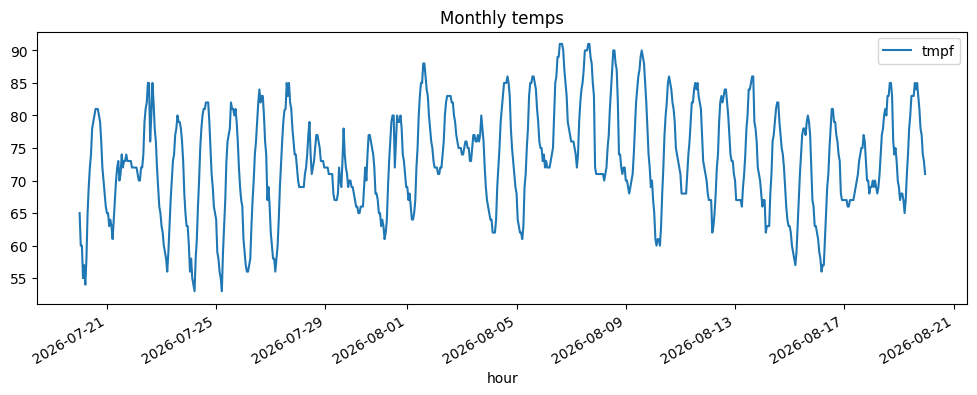

<Figure size 640x480 with 0 Axes>

In [12]:
# TODO

# Plot against TIME, not the row number - the question is WHEN.
#     hourly.plot(x='hour', y='temperature', figsize=(12, 4))
# hourly['temperature'].plot() looks right but puts row 0..743 on the x-axis.
hourly.plot(x='hour', y='tmpf', figsize=(12, 4))
plt.title('Monthly temps')
plt.show()
plt.savefig('MonthlyTemps.png')

## 5. Save it and get it into the repo

**This is the part that matters tonight.** Colab's disk is temporary - the file below
disappears when the runtime disconnects. Getting it into the repo is a deliberate act.

> **Before any notebook goes into the repo:** Runtime → *Restart and run all* (proves it works top-to-bottom, not just in the order you clicked), then Edit → *Clear all outputs*. A notebook committed with outputs buries your 50 lines of code in thousands of lines of noise, and your partner has to review that diff.


In [14]:
hourly.to_csv("weather_hourly.csv", index=False)

from google.colab import files
files.download("weather_hourly.csv")
files.download("MonthlyTemps.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Now, off Colab:

1. Move the downloaded file into your repo folder as `data/clean/weather_hourly.csv`
2. **GitHub Desktop** - you should see it under **Changes**. Confirm you are on branch
   **`dev-weather`** (top of the window!), commit with a real message, then **Push**
3. Back here: **File > Save a copy in GitHub** - repo, branch **`dev-weather`**,
   path `notebooks/weather_eda.ipynb`
4. On github.com: **Compare & pull request**. Ask Partner B to review it.

> If GitHub Desktop says you are on `main`, stop and switch branches first. `main` is
> protected and will reject the push - which is the protection working, not a bug.

### Then write your half of the data dictionary
In the repo `README.md`, document **every column** in `weather_hourly.csv`: name, meaning,
units, and what a missing value means. Partner B is documenting theirs at the same time, in
the same file. Yes, that is going to collide. Read the lab README about that.